In [40]:
"""
Disorder Generation Script
Translated from Mathematica Notebook screenshots (Diss_nb_screenshots.md).

This script generates spatially correlated disorder in 1D systems by:
1. Constructing a discrete sine transform basis (psiKx).
2. Generating random fluctuations in Fourier space.
3. Filtering frequencies using a Gaussian-like envelope (Qdis) parameterized by lambda.
4. Transforming back to real space and standardizing the potential (zero mean, unit variance).

This script uses standard '# %%' markers to divide code into blocks matching the 
Mathematica input cells. You can run this in VS Code Interactive Window or copy-paste
each block directly into a Jupyter Notebook cell.
"""

"\nDisorder Generation Script\nTranslated from Mathematica Notebook screenshots (Diss_nb_screenshots.md).\n\nThis script generates spatially correlated disorder in 1D systems by:\n1. Constructing a discrete sine transform basis (psiKx).\n2. Generating random fluctuations in Fourier space.\n3. Filtering frequencies using a Gaussian-like envelope (Qdis) parameterized by lambda.\n4. Transforming back to real space and standardizing the potential (zero mean, unit variance).\n\nThis script uses standard '# %%' markers to divide code into blocks matching the \nMathematica input cells. You can run this in VS Code Interactive Window or copy-paste\neach block directly into a Jupyter Notebook cell.\n"

In [41]:
import numpy as np
import matplotlib.pyplot as plt

In [42]:
# Parameters
Nx = 300
lambda_val = 9
# Site index ii (1-based index to match Mathematica's indexing conventions)
ii = np.arange(1, Nx + 1)


In [43]:
# Compute Qdis envelope
# Mathematica formula: Tanh[ii/2] * exp(-ii^2 / (4 * (Nx^2) / lambda^2))
# Evaluates left-to-right: 4 * (Nx^2) / lambda^2 -> 4 * Nx^2 / lambda^2
# Hence, exponent = -ii^2 / (4 * Nx^2 / lambda^2) = -ii^2 * lambda^2 / (4 * Nx^2)
Qdis = np.tanh(ii / 2.0) * np.exp(-(ii**2) * (lambda_val**2) / (4.0 * (Nx**2)))

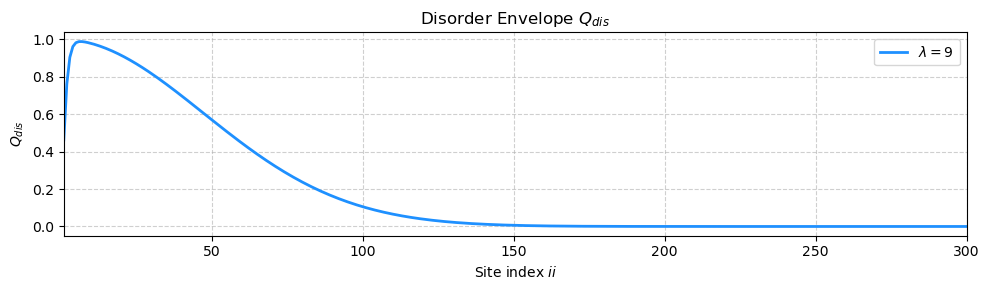

In [44]:
# Plot Qdis
plt.figure(figsize=(10, 3))
plt.plot(ii, Qdis, label=f"$\\lambda = {lambda_val}$", color="dodgerblue", lw=2)
plt.title("Disorder Envelope $Q_{dis}$")
plt.xlabel("Site index $ii$")
plt.ylabel("$Q_{dis}$")
plt.grid(True, linestyle="--", alpha=0.6)
plt.xlim(1, Nx)
plt.legend()
plt.tight_layout()
plt.show()

### Block 2: Setup Core Variables, Basis, and Moments Function
We define the Discrete Sine Transform (DST) basis matrix `psiKx` and the moment estimator `Vn`.

In [45]:
# Clear and reset variables
lambda_val = 4.5  # Mathematica cell has lambda = 9.0; lambda = 4.5; lambda = 9.0; -> final value is 9.0
Nx = 300

# Generate psiKx basis matrix
# psiKx[nn, ii] = Sqrt[2 / (Nx + 1)] * Sin[ii * nn * Pi / (Nx + 1)]
# We shape nn as (Nx, 1) and ii as (1, Nx) to perform outer multiplication
nn_grid = np.arange(1, Nx + 1).reshape(-1, 1)
ii_grid = np.arange(1, Nx + 1).reshape(1, -1)
psiKx = np.sqrt(2.0 / (Nx + 1.0)) * np.sin(ii_grid * nn_grid * np.pi / (Nx + 1.0))

psiKx.shape

(300, 300)

In [46]:
def Vn(vds):
    """
    Computes the first four moments of the input vector vds:
    [Mean, Mean Square (Variance), Mean Cube (Skewness-related), Mean Quartic (Kurtosis-related)]
    """
    length = len(vds)
    m1 = np.sum(vds) / length
    # Chop values very close to zero to mimic Mathematica's Chop function
    if abs(m1) < 1e-10:
        m1 = 0.0
    m2 = np.sum(vds**2) / length
    m3 = np.sum(vds**3) / length
    m4 = np.sum(vds**4) / length
    return [m1, m2, m3, m4]

# Recompute Qdis with lambda = 9.0
Qdis = np.tanh(ii / 2.0) * np.exp(-(ii**2) * (lambda_val**2) / (4.0 * (Nx**2)))

### Block 3: Define Disorder Generation Functions
We implement the functions to generate uniform random disorder in momentum/Fourier space 
and project/normalize it into real space.

In [47]:
def GetVdis():
    """
    Generates random real-space disorder directly.
    1. Generates a uniform random vector vdk in [-1, 1] scaled by the Qdis envelope.
    2. Projects vdk into the real-space sine basis.
    3. Centers to zero mean and normalizes to unit variance.
    """
    vdk = np.random.uniform(-1, 1, Nx) * Qdis
    vtp = psiKx @ vdk
    vtp = vtp - np.mean(vtp)
    v2 = np.mean(vtp**2)
    return vtp / np.sqrt(v2)

def Vdk():
    """
    Generates a raw uniform random vector in [-1, 1].
    """
    return np.random.uniform(-1, 1, Nx)

def VdkQ(vdk_vec):
    """
    Applies the Qdis envelope to a raw random vector.
    """
    return vdk_vec * Qdis

def GetVd(vdk_vec):
    """
    Projects and normalizes a pre-scaled Fourier-space disorder vector.
    """
    vtp = psiKx @ vdk_vec
    vtp = vtp - np.mean(vtp)
    v2 = np.mean(vtp**2)
    return vtp / np.sqrt(v2)

### Block 4: Generate a Sample Disorder Potential and Calculate Moments
#We evaluate a random potential realization `Vdiss` and check its moments using `Vn`.

In [48]:
Vdiss = GetVdis()
moments = Vn(Vdiss)
print("Moments of Vdiss (lambda = 9.0):")
print(f"Mean:         {moments[0]}")
print(f"Mean Square:  {moments[1]}")
print(f"Mean Cube:    {moments[2]:.6f}")
print(f"Mean Quartic: {moments[3]:.4f}")

Moments of Vdiss (lambda = 9.0):
Mean:         0.0
Mean Square:  1.0
Mean Cube:    0.220166
Mean Quartic: 2.6093


### Block 5: Plot the Sample Potential
We visualize the generated potential `Vdiss` using an aspect ratio matching the Mathematica plot.

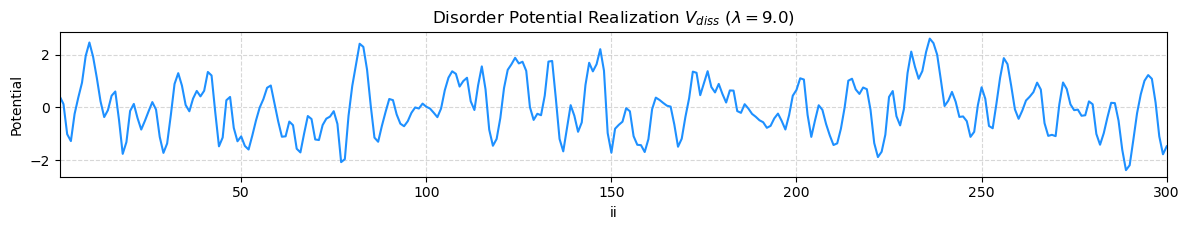

In [49]:
plt.figure(figsize=(12, 2.4))
plt.plot(ii, Vdiss, color="dodgerblue", lw=1.5)
plt.title("Disorder Potential Realization $V_{diss}$ ($\\lambda = 9.0$)")
plt.xlabel("ii")
plt.ylabel("Potential")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(1, Nx)
plt.tight_layout()
plt.show()

### Block 6: Save a Specific Random Fourier Seed
#We generate and save a single raw random vector `Vk1` to compare different lambda envelopes on the same noise realization.


In [50]:
Vk1 = Vdk()


### Block 7: Generate Potential V1 with lambda = 4.5
Using the saved noise realization, we apply a narrower envelope (lambda = 4.5).

In [51]:
lambda_val = 4.5
Qdis = np.tanh(ii / 2.0) * np.exp(-(ii**2) * (lambda_val**2) / (4.0 * (Nx**2)))
vdkq = VdkQ(Vk1)
V1 = GetVd(vdkq)
moments_1 = Vn(V1)
print("Moments of V1 (lambda = 4.5):")
print(f"Mean:         {moments_1[0]}")
print(f"Mean Square:  {moments_1[1]}")
print(f"Mean Cube:    {moments_1[2]:.6f}")
print(f"Mean Quartic: {moments_1[3]:.4f}")

Moments of V1 (lambda = 4.5):
Mean:         0.0
Mean Square:  1.0
Mean Cube:    -0.047084
Mean Quartic: 3.0098


In [52]:
# ### Block 8: Generate Potential V2 with lambda = 9.0
# Using the same saved noise realization, we apply a wider envelope (lambda = 9.0).

# %%
lambda_val = 9.0
Qdis = np.tanh(ii / 2.0) * np.exp(-(ii**2) * (lambda_val**2) / (4.0 * (Nx**2)))
vdkq = VdkQ(Vk1)
V2 = GetVd(vdkq)
moments_2 = Vn(V2)
print("Moments of V2 (lambda = 9.0):")
print(f"Mean:         {moments_2[0]}")
print(f"Mean Square:  {moments_2[1]}")
print(f"Mean Cube:    {moments_2[2]:.6f}")
print(f"Mean Quartic: {moments_2[3]:.4f}")

Moments of V2 (lambda = 9.0):
Mean:         0.0
Mean Square:  1.0
Mean Cube:    -0.161727
Mean Quartic: 3.2117


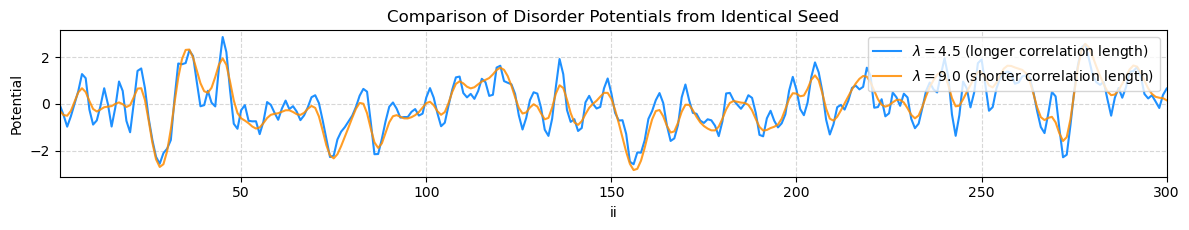

In [53]:
# ### Block 9: Compare the Two Envelopes
# We plot both V1 and V2 together. 
# V1 (lambda = 4.5) is smoother (longer-range correlation) because it filters out higher frequencies.
# V2 (lambda = 9.0) contains faster, shorter-range fluctuations.

# %%
plt.figure(figsize=(12, 2.4))
plt.plot(ii, V1, label="$\\lambda = 4.5$ (longer correlation length)", color="dodgerblue", lw=1.5)
plt.plot(ii, V2, label="$\\lambda = 9.0$ (shorter correlation length)", color="darkorange", lw=1.5, alpha=0.85)
plt.title("Comparison of Disorder Potentials from Identical Seed")
plt.xlabel("ii")
plt.ylabel("Potential")
plt.legend(loc="upper right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(1, Nx)
plt.tight_layout()
plt.show()

In [54]:
import helpers as hp
from pathlib import Path

path = Path("/home/pseudonym/code/Nonlocal_Conductance/Nonlocality-of-local-Andreev-conductances-as-a-probe-for-topological-Majorana-wires/Run_Files/Raw_Disorders/raw_disorder_0.npy")

In [55]:
dis_raw = np.load(path)

dis1 = hp.generate_disorder_from_raw(dis_raw, 9, 300)
dis2 = hp.generate_disorder_from_raw(dis_raw, 6, 300)

np.sum(dis1 - dis2)

-9.769962616701378e-15

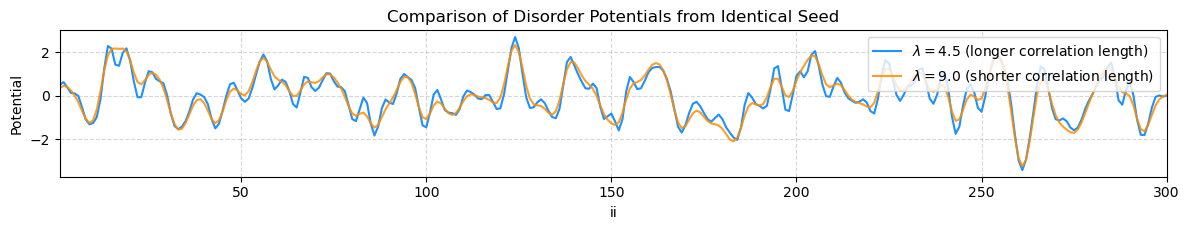

In [56]:
# %%
plt.figure(figsize=(12, 2.4))
plt.plot(ii, dis2, label="$\\lambda = 4.5$ (longer correlation length)", color="dodgerblue", lw=1.5)
plt.plot(ii, dis1, label="$\\lambda = 9.0$ (shorter correlation length)", color="darkorange", lw=1.5, alpha=0.85)
plt.title("Comparison of Disorder Potentials from Identical Seed")
plt.xlabel("ii")
plt.ylabel("Potential")
plt.legend(loc="upper right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(1, Nx)
plt.tight_layout()
plt.show()

In [57]:
import plotly.graph_objects as go

def plot_2d_heatmap(data_array):
    """
    Plots a 2D numpy array as a heatmap.
    
    Parameters:
    - data_array: 2D numpy array to be visualized.
    """
    # Initialize the Heatmap figure. 
    # The 'z' parameter automatically extracts the 2D dimensions.
    fig = go.Figure(data=go.Heatmap(
        z=data_array,
        colorscale='Viridis',  # Perceptually uniform colorscale (standard for physics)
        colorbar=dict(title="Value")
    ))
    
    # Enforce correct matrix coordinate mapping
    fig.update_layout(
        title="2D Array Heatmap",
        xaxis_title="Array Columns (X)",
        yaxis_title="Array Rows (Y)",
        yaxis_autorange='reversed', # Crucial: aligns array index (0,0) with top-left
        width=700,
        height=700
    )
    
    # In browser or standard environments, this will render the interactive plot
    fig.show()

In [67]:
#SMDisStrongMapNy1

maps = np.loadtxt('SMDisStrongMapNy1.dat', delimiter='	')

# Verify the shape of your 2D array

muvar = np.arange(-1, 3 + 1e-9, step=0.01)
gmvar = np.arange(0.34, 1.22 + 1e-9, step=0.01)
phase_map_data = maps[5,:]

(gmvar.shape[0] * muvar.shape[0])

35689

In [70]:
import plotly.graph_objects as go

# Reshape the 1D phase map data to a 2D grid of shape (len(muvar), len(gmvar))
grid_data = phase_map_data.reshape(len(muvar), len(gmvar))

# Create the Plotly heatmap
fig = go.Figure(data=go.Heatmap(
    x=gmvar,
    y=muvar,
    z=grid_data,
    colorscale='Viridis',
    colorbar=dict(title='Topological Invariant $\nu$')
))

# Update layout for labels and title
fig.update_layout(
    title='Phase Diagram Map ($\Delta N = 10$, Layer 6)',
    xaxis_title='Zeeman Field $\Gamma$ (meV)',
    yaxis_title='Chemical Potential $\mu$ (meV)',
    width=800,
    height=600
)

fig.show()

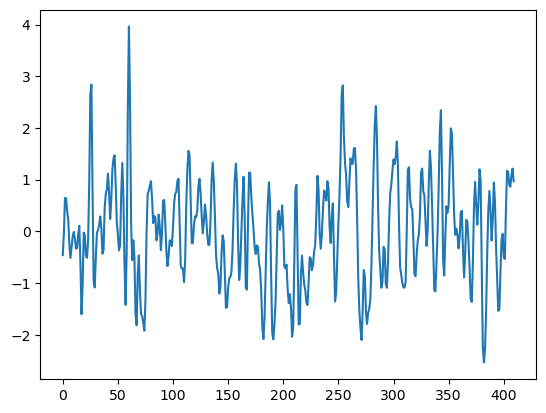

In [69]:
disorder = np.loadtxt('SMVdissNy1.dat', delimiter='\t')

plt.plot(disorder)